In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/lokeshparab/amazon-products-dataset/Gaming Consoles.csv
/kaggle/input/datasets/lokeshparab/amazon-products-dataset/Car Electronics.csv
/kaggle/input/datasets/lokeshparab/amazon-products-dataset/Janitorial and Sanitation Supplies.csv
/kaggle/input/datasets/lokeshparab/amazon-products-dataset/All Electronics.csv
/kaggle/input/datasets/lokeshparab/amazon-products-dataset/All Books.csv
/kaggle/input/datasets/lokeshparab/amazon-products-dataset/Make-up.csv
/kaggle/input/datasets/lokeshparab/amazon-products-dataset/Travel Accessories.csv
/kaggle/input/datasets/lokeshparab/amazon-products-dataset/Indian Language Books.csv
/kaggle/input/datasets/lokeshparab/amazon-products-dataset/Car and Bike Care.csv
/kaggle/input/datasets/lokeshparab/amazon-products-dataset/Sunglasses.csv
/kaggle/input/datasets/lokeshparab/amazon-products-dataset/Bags and Luggage.csv
/kaggle/input/datasets/lokeshparab/amazon-products-dataset/Yoga.csv
/kaggle/input/datasets/lokeshparab/amazon-products-

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

plt.style.use('ggplot')
print('All libraries loaded')

All libraries loaded


In [3]:
import os
import pandas as pd
import glob

# Load all category CSVs and combine them
path = '/kaggle/input/datasets/lokeshparab/amazon-products-dataset/'
all_files = glob.glob(path + '*.csv')

df_list = []
for f in all_files:
    try:
        temp = pd.read_csv(f)
        category = f.split('/')[-1].replace('.csv', '')
        temp['main_category'] = category
        df_list.append(temp)
    except:
        pass

df = pd.concat(df_list, ignore_index=True)
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Shape: (1103170, 10)
Columns: ['name', 'main_category', 'sub_category', 'image', 'link', 'ratings', 'no_of_ratings', 'discount_price', 'actual_price', 'Unnamed: 0']


,name,main_category,sub_category,image,link,ratings,no_of_ratings,discount_price,actual_price,Unnamed: 0
0,Electronic Spices 2.75 Inch 4ω (Ohm) 400w Max ...,Car Electronics,Car Electronics,https://m.media-amazon.com/images/I/61G5k3T0ff...,https://www.amazon.in/Electronic-Spices-Power-...,NaN,NaN,₹129,₹199,NaN
1,"ZQWINT Bluetooth Car Adapter, Mini USB Bluetoo...",Car Electronics,Car Electronics,https://m.media-amazon.com/images/I/51NLOKwNsL...,https://www.amazon.in/ZQWINT-Bluetooth-Transmi...,NaN,NaN,₹219,₹999,NaN
2,PROTECTRON 6.35X32mm GLASS FUSE/INVERTER FUSE ...,Car Electronics,Car Electronics,https://m.media-amazon.com/images/I/71St2ruv+N...,https://www.amazon.in/PROTECTRON-6-35X32mm-GLA...,3.8,32,NaN,₹105,NaN


In [4]:
#Data Cleaning
cols_needed = ['name','main_category','sub_category','ratings','no_of_ratings','discount_price','actual_price']
df = df[cols_needed].copy()
# Clean price columns(remove ₹ and commas)
def clean_price(val):
    try:
        return float(str(val).replace('₹','').replace(',','').strip())
    except:
        return np.nan
df['discount_price'] = df['discount_price'].apply(clean_price)
df['actual_price']   = df['actual_price'].apply(clean_price)
df['ratings']        = pd.to_numeric(df['ratings'], errors='coerce')
df['no_of_ratings']  = df['no_of_ratings'].apply(clean_price)
# Drop missing
df.dropna(subset=['discount_price', 'actual_price', 'ratings'], inplace=True)
df = df[df['discount_price'] > 0]
df.reset_index(drop=True, inplace=True)
# Calculate discount percentage
df['discount_pct'] = ((df['actual_price'] - df['discount_price']) / df['actual_price'] * 100).round(2)
print(f'Clean dataset shape: {df.shape}')
print(f'Categories: {df["main_category"].nunique()}')
df.head(3)

Clean dataset shape: (669926, 8)
Categories: 113


,name,main_category,sub_category,ratings,no_of_ratings,discount_price,actual_price,discount_pct
0,Cave Maruti Suzuki Male-Female Stereo Coupler ...,Car Electronics,Car Electronics,4.1,7.0,582.0,873.0,33.33
1,Die Hard Dual Purpose 360-Degree Rotating Mobi...,Car Electronics,Car Electronics,5.0,2.0,335.0,1299.0,74.21
2,WEON® Tiny Subwoofer Preamp kit with Volume Co...,Car Electronics,Car Electronics,3.1,4.0,313.0,396.0,20.96


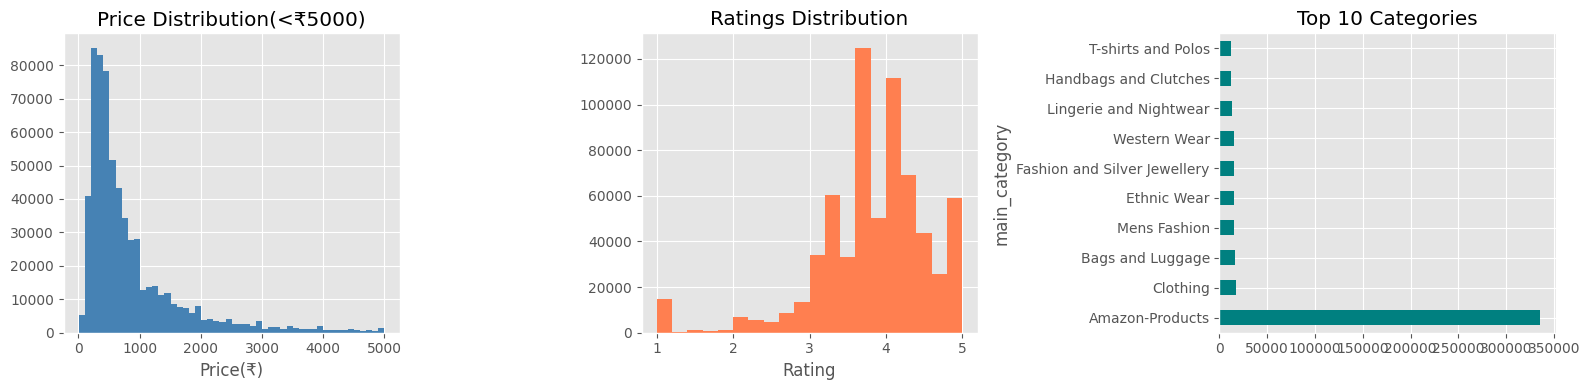

In [5]:
#EDA
fig, axes = plt.subplots(1,3,figsize=(16,4))
# Price distribution
df[df['discount_price']<5000]['discount_price'].hist(bins=50,ax=axes[0],color='steelblue')
axes[0].set_title('Price Distribution(<₹5000)')
axes[0].set_xlabel('Price(₹)')
# Ratings distribution
df['ratings'].hist(bins=20,ax=axes[1],color='coral')
axes[1].set_title('Ratings Distribution')
axes[1].set_xlabel('Rating')
# Top categories
df['main_category'].value_counts().head(10).plot(kind='barh',ax=axes[2],color='teal')
axes[2].set_title('Top 10 Categories')
plt.tight_layout()
plt.show()

In [6]:
# Formula: value_score=(rating*log(reviews+1))/log(price+1)
df['value_score'] = (
    df['ratings'] * np.log1p(df['no_of_ratings'].fillna(1))
) / np.log1p(df['discount_price'])
# Normalize to 0-100
df['value_score'] = (
    (df['value_score'] - df['value_score'].min()) /
    (df['value_score'].max() - df['value_score'].min()) * 100
).round(2)
print('Value Score calculated!')
print(df[['name','discount_price','ratings','value_score']].head())

Value Score calculated!
                                                name  discount_price  ratings  \
0  Cave Maruti Suzuki Male-Female Stereo Coupler ...           582.0      4.1   
1  Die Hard Dual Purpose 360-Degree Rotating Mobi...           335.0      5.0   
2  WEON® Tiny Subwoofer Preamp kit with Volume Co...           313.0      3.1   
3  jiaruixin 6 Volt Kids Ride On Car Charger, 6V ...           593.0      4.2   
4  Ceuta Retails Motorcycle Phone Holder with USB...           440.0      3.1   

   value_score  
0         5.52  
1         3.82  
2         3.49  
3        13.60  
4        12.85  


In [7]:
#PRICE PREDICTION
# Predict actual_price→if discount_price << predicted→great deal!
le_cat = LabelEncoder()
le_sub = LabelEncoder()
df['cat_enc'] = le_cat.fit_transform(df['main_category'].astype(str))
df['sub_enc'] = le_sub.fit_transform(df['sub_category'].astype(str))
features = ['cat_enc','sub_enc','ratings','no_of_ratings','discount_pct']
X = df[features].fillna(0)
y = df['actual_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print('PRICE PREDICTION MODEL')
print(f'MAE: ₹{mean_absolute_error(y_test, y_pred):.2f}')
print(f'R²: {r2_score(y_test, y_pred):.4f}')
# Add predicted fair price to dataframe
df['predicted_fair_price']=rf.predict(X).round(2)
df['deal_score']=((df['predicted_fair_price']-df['discount_price'])/df['predicted_fair_price']*100).round(2)
df['deal_score']=df['deal_score'].clip(0, 100)
print('Fair price prediction done!')

PRICE PREDICTION MODEL
MAE: ₹1232.66
R²: 0.7662
Fair price prediction done!


In [8]:
#BUDGET OPTIMIZER
# Given a list of items + budget → find best combination
def budget_optimizer(item_list, budget, df, top_n=3):
    """
    Given a list of items and a budget,
    returns the best products for each item within budget.
    """
    print(f'\n{' '*55}')
    print(f' SMART BUDGET RECOMMENDER')
    print(f' Items :{", ".join(item_list)}')
    print(f' Budget:₹{budget:,}')
    print(f'{' '*55}')
    budget_per_item=budget/len(item_list)
    total_spent=0
    recommendations={}
    for item in item_list:
        # Search for item in dataset
        mask = (
            df['name'].str.contains(item, case=False, na=False) |
            df['main_category'].str.contains(item, case=False, na=False) |
            df['sub_category'].str.contains(item, case=False, na=False)
        )
        filtered=df[mask & (df['discount_price']<=budget_per_item*1.2)].copy()
        if filtered.empty:
            # Relax budget constraint
            filtered=df[mask].copy()
        if filtered.empty:
            print(f'\nNo products found for: {item}')
            continue
        # Sort by combined score (value + deal)
        filtered['final_score']=filtered['value_score']*0.5+filtered['deal_score']*0.5
        top = filtered.nlargest(top_n,'final_score')[[
            'name','discount_price','actual_price',
            'ratings','value_score','deal_score','final_score'
        ]]
        recommendations[item]=top
        best_price=top.iloc[0]['discount_price']
        total_spent+=best_price
        print(f'\n{item.upper()}—Top{top_n} picks:')
        for i, row in top.iterrows():
            print(f"{''*int(row['ratings'])}{row['name'][:55]}")
            print(f" Price: ₹{row['discount_price']:,.0f}  "
                  f"(was ₹{row['actual_price']:,.0f})  "
                  f"Value:{row['value_score']:.1f}/100  "
                  f"Deal:{row['deal_score']:.1f}/100")
    print(f'\n{' '*55}')
    print(f' Estimated total (best picks): ₹{total_spent:,.0f}')
    remaining=budget-total_spent
    if remaining>=0:
        print(f' Within budget! Savings: ₹{remaining:,.0f}')
    else:
        print(f' Over budget by: ₹{abs(remaining):,.0f}')
    print(f'{' '*55}')
    return recommendations
print('Budget Optimizer ready!')

Budget Optimizer ready!


In [9]:
my_items  = ['laptop','headphones','mouse']
my_budget = 60000   # ₹60,000 total budget
results = budget_optimizer(my_items, my_budget, df, top_n=3)


                                                       
 SMART BUDGET RECOMMENDER
 Items :laptop, headphones, mouse
 Budget:₹60,000
                                                       

LAPTOP—Top3 picks:
Amazon Basics USB Type C to USB A 2.0 Male Fast Chargin
 Price: ₹159  (was ₹845)  Value:39.0/100  Deal:92.6/100
Amazon Basics USB Type C to USB A 2.0 Male Fast Chargin
 Price: ₹159  (was ₹845)  Value:39.0/100  Deal:92.5/100
Set of 2 piece Mini USB LED Light Adjust Angle / bendab
 Price: ₹71  (was ₹499)  Value:34.8/100  Deal:92.3/100

HEADPHONES—Top3 picks:
Philips Audio SHE1505 Wired in Ear Earphones with Mic (
 Price: ₹329  (was ₹399)  Value:29.8/100  Deal:95.4/100
Philips Audio SHE1505 Wired in Ear Earphones with Mic (
 Price: ₹329  (was ₹399)  Value:29.8/100  Deal:94.8/100
PHILIPS Audio TAE1136 Wired in Ear Earphones with Built
 Price: ₹229  (was ₹699)  Value:31.8/100  Deal:89.7/100

MOUSE—Top3 picks:
Redgear MP35 Speed-Type Gaming Mousepad (Black/Red)
 Price: ₹219  (was ₹550) 

In [10]:
my_items  = ['phone', 'earbuds', 'charger']
my_budget = 25000
results2 = budget_optimizer(my_items, my_budget, df, top_n=3)


                                                       
 SMART BUDGET RECOMMENDER
 Items :phone, earbuds, charger
 Budget:₹25,000
                                                       

PHONE—Top3 picks:
Amazon Basics Micro Usb Fast Charging Cable For Android
 Price: ₹239  (was ₹395)  Value:37.6/100  Deal:95.8/100
STRIFF Multi Angle Mobile Tabletop Stand. Phone Holder 
 Price: ₹119  (was ₹499)  Value:41.2/100  Deal:92.0/100
STRIFF Multi Angle Mobile Tabletop Stand. Phone Holder 
 Price: ₹119  (was ₹499)  Value:41.2/100  Deal:91.4/100

EARBUDS—Top3 picks:
3M 1110 Ear Plugs Corded, Extra Soft, Reusable Earbuds 
 Price: ₹16  (was ₹1,600)  Value:58.5/100  Deal:99.6/100
3M 1110 Ear Plugs Corded, Extra Soft, Reusable Earbuds 
 Price: ₹16  (was ₹1,600)  Value:58.5/100  Deal:99.6/100
3M 1110 Ear Plugs Corded, Extra Soft, Reusable Earbuds 
 Price: ₹16  (was ₹1,600)  Value:58.5/100  Deal:99.4/100

CHARGER—Top3 picks:
LAPSTER Spiral Charger Spiral Charger Cable Protectors 
 Price: ₹81  (was ₹99

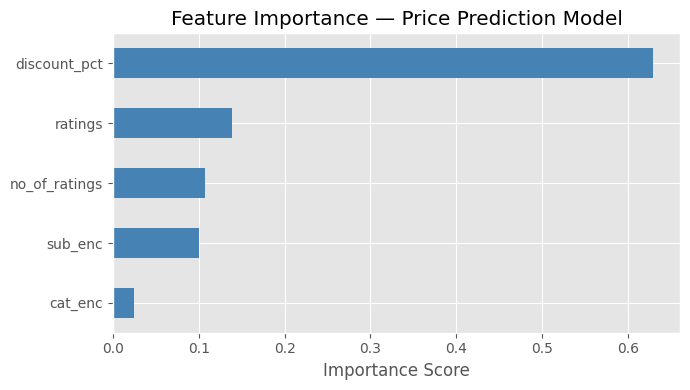

In [11]:
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
plt.figure(figsize=(7, 4))
feat_imp.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Price Prediction Model')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [12]:
#Top Value Products per Category
top_value = (
    df.groupby('main_category')
    .apply(lambda x: x.nlargest(1, 'value_score'))
    .reset_index(drop=True)
)[['main_category','name','discount_price','ratings','value_score']]
print('Best Value Product per Category:')
print(top_value.to_string(index=False))

Best Value Product per Category:
                             main_category                                                                                                                          name  discount_price  ratings  value_score
                          Air Conditioners ThreeH USB Fan Silent Mini Air Conditioner Travel Handheld USB Rechargeable Fan Air Purifier Humidifier Cooling Fan F015,P...         1219.00      4.0        17.34
                            All Appliances Pigeon Polypropylene Mini Handy and Compact Chopper with 3 Blades for Effortlessly Chopping Vegetables and Fruits for Your...          199.00      4.1        41.55
            All Car and Motorbike Products SOFTSPUN Microfiber Cloth - 4 pcs - 40x40 cms - 340 GSM Grey- Thick Lint & Streak-Free Multipurpose Cloths - Automotive Mi...          269.00      4.3        37.11
                           All Electronics                                                    Amazon Basics Flexible Premium HDMI Cable (Bl

In [13]:
print(' '*50)
print('SMART BUDGET SHOPPING RECOMMENDER')
print('Model Performance Summary')
print(' '*50)
print(f'Dataset size       : {len(df):,} products')
print(f'Categories covered : {df["main_category"].nunique()}')
print(f'Price range        : ₹{df["discount_price"].min():,.0f} — ₹{df["discount_price"].max():,.0f}')
print(f'Avg rating         : {df["ratings"].mean():.2f} / 5')
print()
print('ML Models Used:')
print(f'  1. Value Score    : Rating × Reviews / Price formula')
print(f'  2. Price Predictor: Random Forest  R²={r2_score(y_test, y_pred):.3f}  MAE=₹{mean_absolute_error(y_test, y_pred):.0f}')
print(f'  3. Budget Optimizer: Greedy best-value selection')


                                                  
SMART BUDGET SHOPPING RECOMMENDER
Model Performance Summary
                                                  
Dataset size       : 669,926 products
Categories covered : 113
Price range        : ₹8 — ₹1,249,990
Avg rating         : 3.81 / 5

ML Models Used:
  1. Value Score    : Rating × Reviews / Price formula
  2. Price Predictor: Random Forest  R²=0.766  MAE=₹1233
  3. Budget Optimizer: Greedy best-value selection
